# Pagoda2.1 CITE-seq Workflow (RNA + protein)

pagoda2.1 can analyze datasets with **more than one molecular modality**
measured in the same cells — CITE-seq (gene expression + surface-protein
antibody counts), 10x multiome (gene expression + chromatin
accessibility), and so on. Each modality is represented as a **facet**.

A facet bundles everything specific to one modality: its raw count
matrix, the normalization *view recipe* appropriate for that modality,
and the reductions computed from it. All facets share the same cells.
When you load an ordinary count matrix, pagoda2 creates a single
**default facet** named `RNA` — so a plain scRNA-seq analysis (the
[single-dataset notebook](pagoda2.1-single-dataset.ipynb)) never
mentions facets at all. Additional modalities become additional facets,
and the analysis verbs gain a `facet =` argument (act on one modality)
or a `facets =` argument (integrate across them).

This notebook uses a CITE-seq sample — 10x [PBMC 1k protein
v3](https://www.10xgenomics.com/datasets/1-k-pbm-cs-using-3-prime-feature-barcoding-3-standard-3-0-0)
— which carries RNA (“Gene Expression”) and a 17-antibody
surface-protein panel (“Antibody Capture”). We reduce each modality on
its own terms and then integrate them with **weighted nearest neighbors
(WNN)** into a single joint clustering and embedding. The 10x file is in
a local folder named `data`.

## Import: one object, two facets

A multimodal 10x HDF5 records a `feature_type` for every feature;
pagoda2 reads it and builds one facet per modality automatically. Each
facet gets the normalization view model appropriate for its modality —
RNA uses `plain` (library-size normalize, then `log1p`); CITE-seq
protein uses `clr`, the centered log-ratio across the antibody panel
within each cell, which removes per-cell differences in total antibody
capture (a small, compositional panel where raw counts are not
comparable across cells).

In [ ]:
p2 <- pagoda2::Pagoda2$from10xH5("data/pbmc_1k_protein_v3_filtered_feature_bc_matrix.h5", verbose = FALSE)
sapply(p2$listFacets(), function(f) p2$getFacet(f)$modelType)   # facet -> view model

    RNA     ADT 
"plain"   "clr" 

Both facets cover the same cells. `RNA` is the default facet, so steps
written without a `facet=` argument act on it.

## QC

`runQC()` computes per-cell quality metrics on the RNA facet — molecule
and detected-gene counts and a gene-vs-molecule pass/fail flag — and
records them in `p2$cellMeta`.

In [ ]:
p2$runQC(verbose = FALSE)

## Reduce each modality on its own terms

The pipeline verbs are generic: the algorithm is chosen by `method=`, so
the same `runReduction()` does PCA on RNA and (in the multiome notebook)
LSI on ATAC — there is no `runPCA`/`runLeiden`. Here we model gene
variance and run PCA on the overdispersed RNA genes, and separately run
PCA on the CLR-transformed protein panel. Reduction scores are stored
under name-keyed slots — the default facet’s is `reductions[["PCA"]]`,
the ADT facet’s is `reductions[["ADT:PCA"]]`.

In [ ]:
p2$runVariance(verbose = FALSE)
p2$runReduction(nPcs = 25, verbose = FALSE)
p2$runVariance(facet = "ADT", use.raw.variance = TRUE, verbose = FALSE)
p2$runReduction(facet = "ADT", nPcs = 15, verbose = FALSE)
names(p2$reductions)

[1] "PCA"     "ADT:PCA"

## Integrate the modalities with WNN

With a reduction per modality, we integrate. **WNN** (weighted nearest
neighbors; Hao et al., *Cell* 2021) asks, for each cell, how well its
neighbors in each modality predict that cell’s own profile, and turns
the answer into a **per-cell weight for each modality**. A cell whose
protein neighbors are more predictive than its RNA neighbors leans on
protein, and vice versa — the integration is local, not a single global
mixing ratio. WNN then fuses the per-modality neighbor graphs weighted
this way into one graph.

`runGraph(method = "wnn")` produces the per-cell weights
(`cellMeta$wnn_weight_RNA`, `..._ADT`), the fused graph
(`graphs[["WNN"]]`), and a joint reduction for embedding
(`reductions[["WNN"]]`). We then cluster on the fused graph with Leiden.

In [ ]:
p2$runGraph(method = "wnn", facets = c("RNA", "ADT"), verbose = FALSE)
p2$runClustering(graph = "WNN", name = "wnn_leiden")

## What each modality resolves

Why integrate at all? Because different populations are best
distinguished by different modalities. To see this directly, we embed
each facet’s own reduction *and* the joint WNN reduction, then color all
three UMAPs by the **same** joint clusters. Where a panel mixes cluster
colors together, that modality alone cannot separate those cells; where
the WNN panel pulls them apart, integration recovered the distinction.

In [ ]:
p2$runEmbedding(reduction = "PCA", name = "umap", verbose = FALSE)        # RNA alone
p2$runEmbedding(reduction = "ADT:PCA", name = "umap", verbose = FALSE)    # protein alone
p2$runEmbedding(reduction = "WNN", name = "umap", verbose = FALSE)        # joint

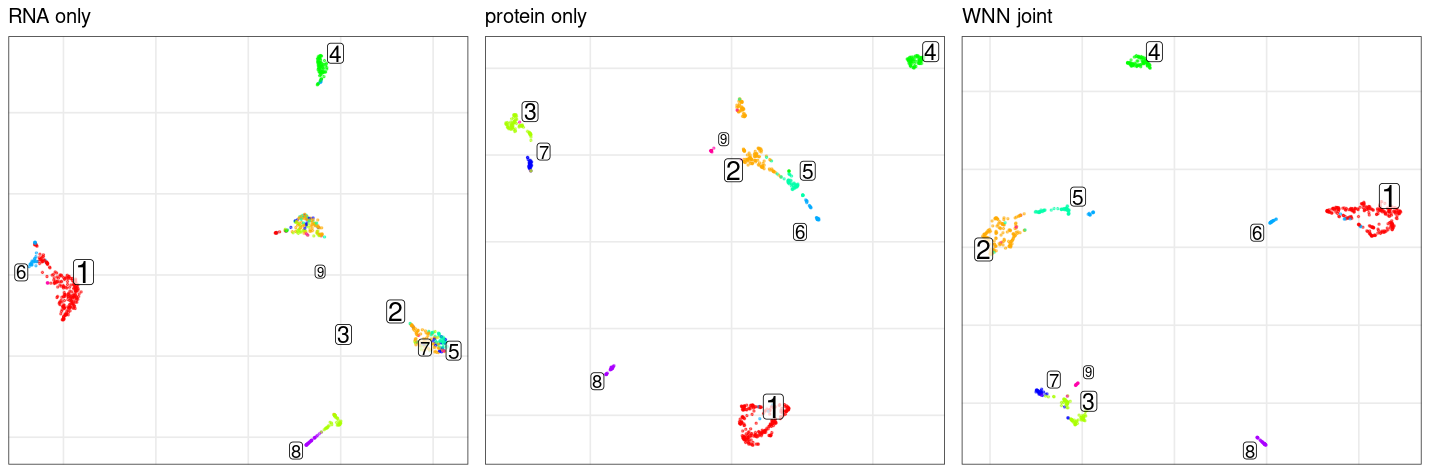

In [ ]:
g_rna <- p2$plotEmbedding(reduction = "PCA", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "RNA only")
g_adt <- p2$plotEmbedding(reduction = "ADT:PCA", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "protein only")
g_wnn <- p2$plotEmbedding(reduction = "WNN", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "WNN joint")
cowplot::plot_grid(g_rna, g_adt, g_wnn, nrow = 1)

RNA alone tends to merge the T-cell subsets; the protein panel separates
them (by CD4/CD8/CD45RA/RO) but is coarser elsewhere; the WNN joint
embedding combines the two. The per-cell ADT weight below maps where
protein, rather than RNA, was the more informative modality — typically
the protein-defined immune subsets.

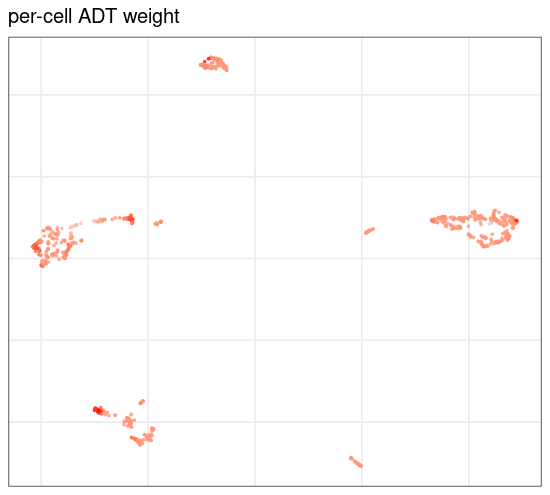

In [ ]:
p2$plotEmbedding(reduction = "WNN", embedding = "umap",
                 colors = stats::setNames(p2$cellMeta$wnn_weight_ADT, rownames(p2$cellMeta)),
                 size = 0.5, alpha = 0.7, title = "per-cell ADT weight")

## Markers

We call marker genes on the RNA facet (the directly interpretable
modality) for the joint clusters. The dot plot shows the top markers per
cluster — color is mean expression, dot size is the fraction of cells
expressing the gene.

In [ ]:
p2$runMarkers(grouping = "wnn_leiden", name = "wnn_markers", verbose = FALSE)

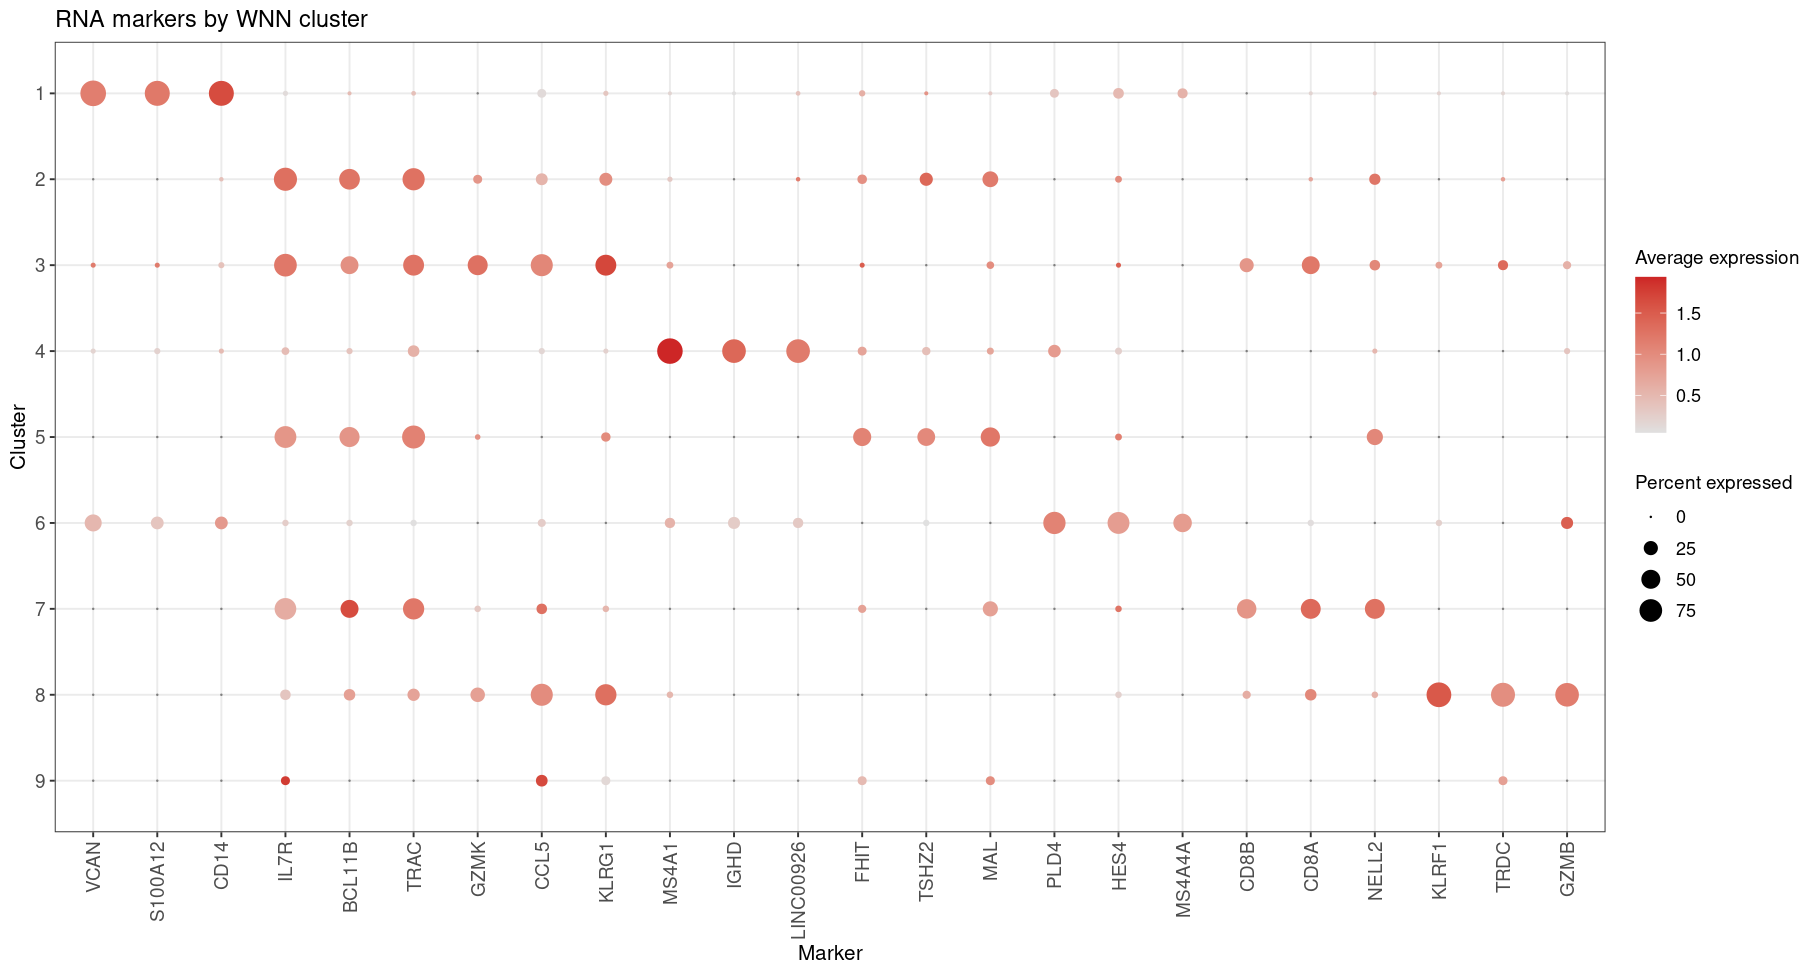

In [ ]:
p2$plotMarkerDotPlot(markers = "wnn_markers", n.genes.per.group = 3, selection = "balanced",
                     order.groups = TRUE, dot.scale = 6) +
  ggplot2::labs(title = "RNA markers by WNN cluster") +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5))

On the protein side every antibody is detected in nearly every cell —
that is exactly what CLR normalizes — so a dot plot’s “fraction
expressing” dimension carries no information. The clearer summary is the
mean CLR of each protein across clusters
(`getExpressionBlock(facet = "ADT")` returns the CLR matrix). The
canonical surface markers light up the joint clusters: CD3/CD4/CD8 on T
cells, CD19 on B cells, CD14/CD15 on monocytes, CD16/CD56 on NK.

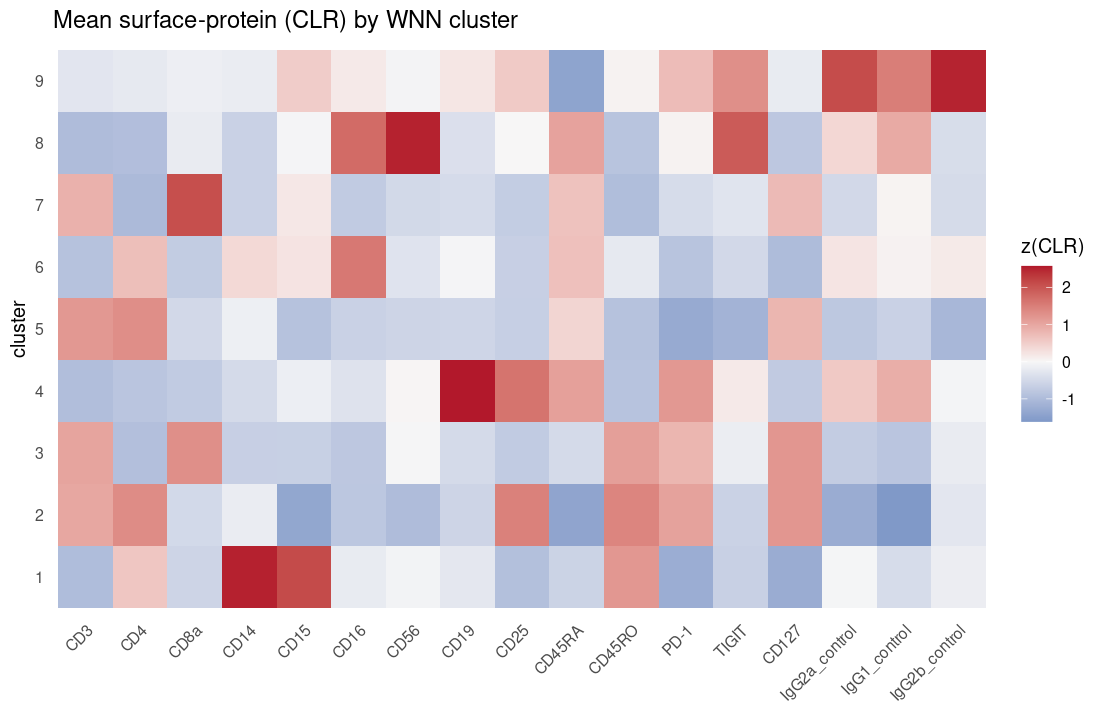

In [ ]:
adt <- as.matrix(p2$getExpressionBlock(facet = "ADT"))                                  # cells x proteins, CLR
prot <- t(sapply(split(rownames(adt), p2$cellMeta[rownames(adt), "wnn_leiden"]),        # mean per cluster
                 function(cells) colMeans(adt[cells, , drop = FALSE])))
colnames(prot) <- sub("_TotalSeqB$", "", colnames(prot))
z <- scale(prot)                                                                        # z-score per protein
df <- data.frame(cluster = rownames(z)[row(z)], protein = factor(colnames(z)[col(z)], colnames(z)), z = c(z))
ggplot2::ggplot(df, ggplot2::aes(protein, cluster, fill = z)) +
  ggplot2::geom_tile() +
  ggplot2::scale_fill_gradient2(low = "#2166ac", mid = "grey97", high = "#b2182b", name = "z(CLR)") +
  ggplot2::theme_minimal(base_size = 11) +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 45, hjust = 1), panel.grid = ggplot2::element_blank()) +
  ggplot2::labs(title = "Mean surface-protein (CLR) by WNN cluster", x = NULL, y = "cluster")

## Next steps

The RNA and protein evidence together name each WNN cluster; record the
annotation and make it the default grouping with
`p2$annotateClusters(from = "wnn_leiden", to = "cell_type", map = ..., setDefault = TRUE)`,
after which every plot uses it. Other integration choices exist at the
reduction level
(`p2$runReduction(facets = c("RNA","ADT"), method = "cca")`), and any
feature from any facet can color the embedding
(`p2$plotEmbedding(gene = "CD3_TotalSeqB", facet = "ADT")`). See the
[single-dataset](pagoda2.1-single-dataset.ipynb) (RNA) and [ATAC /
multiome](pagoda2.1-multiome.ipynb) (RNA + chromatin) notebooks for the
other modalities.